# 01 - Points, and why they fail

The job: given a 3D scene and a camera, produce a 2D image.

One rule governs this project: nothing gets introduced until a problem in front
of us forces it. So we start with the simplest scene and camera we can write
down, render, and watch where it breaks. The break decides what comes next.

Simplest scene: a list of colored points, each a world position plus an RGB.
Simplest camera: a pinhole.

## The pinhole

Camera at the origin. Light passes through a single hole and lands on a plane
at distance $f$. Flip the plane in front of the hole to avoid the upside-down
image, and a scene point at camera coordinates $(x, y, z)$ lands at

$$x_\text{img} = \frac{f x}{z}, \qquad y_\text{img} = \frac{f y}{z}$$

Similar triangles, nothing else. Everything divides by depth.

Image-plane units are scene units. Convert to pixels with the sensor's
pixels-per-unit and the pixel location of the optical axis:

$$u = f_x \frac{x}{z} + c_x, \qquad v = f_y \frac{y}{z} + c_y$$

$f_x, f_y$ are focal lengths in pixels. $(c_x, c_y)$ is where the optical
axis pierces the image, normally the center.

## Axis convention

Pick one and write it down. A sign error here produces a picture that looks
almost right, which is the worst kind of bug.

This project uses `+x` right, `+y` down, `+z` forward, for both camera and
world. Reasons: image memory is stored top-row-first, so `+y` down means the
row index `v` needs no flip; it is what OpenCV and COLMAP emit, so real
capture data will arrive in it; and with `y` down it is right-handed
(right cross down = forward). Under this convention "world up" is `(0, -1, 0)`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
N = 20_000
th = rng.uniform(0, 2 * np.pi, N)
ph = np.arccos(rng.uniform(-1, 1, N))
P = np.stack([np.sin(ph) * np.cos(th),
              np.sin(ph) * np.sin(th),
              np.cos(ph)], axis=-1)     # points on the unit sphere
C = (P + 1) / 2                          # color = position, so shape is readable

## Moving the camera

Points live in world space; the projection assumes camera space. The camera's
three axes, written as world vectors, are the bridge:

```
f = normalize(target - eye)     # forward, camera +z
r = normalize(cross(f, up))     # right,   camera +x
d = cross(f, r)                 # down,    camera +y
```

Stack `[r; d; f]` as rows: multiplying a world vector by this matrix returns
its components along the camera axes, which is exactly camera coordinates.
Subtract `eye` first so the camera sits at the origin, where the pinhole
formula assumed it was.

In [2]:
def look_at(eye, target, up=(0, -1, 0)):
    eye, target, up = (np.asarray(a, float) for a in (eye, target, up))
    f = target - eye
    f = f / np.linalg.norm(f)
    r = np.cross(f, up)
    r = r / np.linalg.norm(r)
    d = np.cross(f, r)
    return np.stack([r, d, f])

R = look_at([0, 0, -4], [0, 0, 0])
assert np.allclose(R @ R.T, np.eye(3))          # orthonormal
assert np.isclose(np.linalg.det(R), 1.0)        # a rotation, not a reflection
R

array([[ 1.,  0., -0.],
       [-0.,  1.,  0.],
       [ 0.,  0.,  1.]])

## The renderer

Two lines below are load-bearing.

The `z > 1e-4` cull: points at `z <= 0` sit at or behind the pinhole, and the
division maps them to a mirrored position in front of the camera. Without the
test, the scene behind you gets drawn, inverted, on top of the scene in front.

The `argsort(-z)`: numpy fancy indexing with duplicate targets is
last-write-wins. Writing far-to-near leaves the nearest point in each pixel.
Delete the sort and the back of the sphere shows through the front, because
array order has nothing to do with visibility.

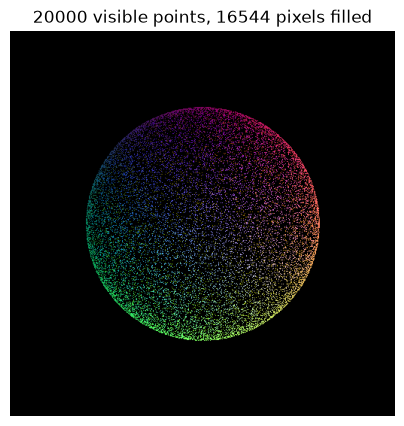

In [3]:
def render_points(P, C, eye, H=512, W=512, fx=600.0, fy=600.0):
    cx, cy = W / 2, H / 2
    R = look_at(eye, [0, 0, 0])
    Xc = (P - np.asarray(eye, float)) @ R.T
    front = Xc[:, 2] > 1e-4
    Xc, col = Xc[front], C[front]
    z = Xc[:, 2]
    u = np.round(fx * Xc[:, 0] / z + cx).astype(int)
    v = np.round(fy * Xc[:, 1] / z + cy).astype(int)
    vis = (u >= 0) & (u < W) & (v >= 0) & (v < H)
    u, v, col, z = u[vis], v[vis], col[vis], z[vis]
    order = np.argsort(-z)                       # far first, near overwrites
    img = np.zeros((H, W, 3))
    img[v[order], u[order]] = col[order]
    filled = len(np.unique(v.astype(np.int64) * W + u))
    return img, len(z), filled

img, nvis, nfill = render_points(P, C, eye=[0, 0, -4])
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title(f"{nvis} visible points, {nfill} pixels filled")
plt.show()

A sphere-shaped cloud of confetti. The background shows through everywhere.

## Make it worse: walk toward it

Same 20,000 points at three camera distances. The silhouette disk area grows
as the camera approaches; the number of pixels the points can fill cannot
exceed the point count.

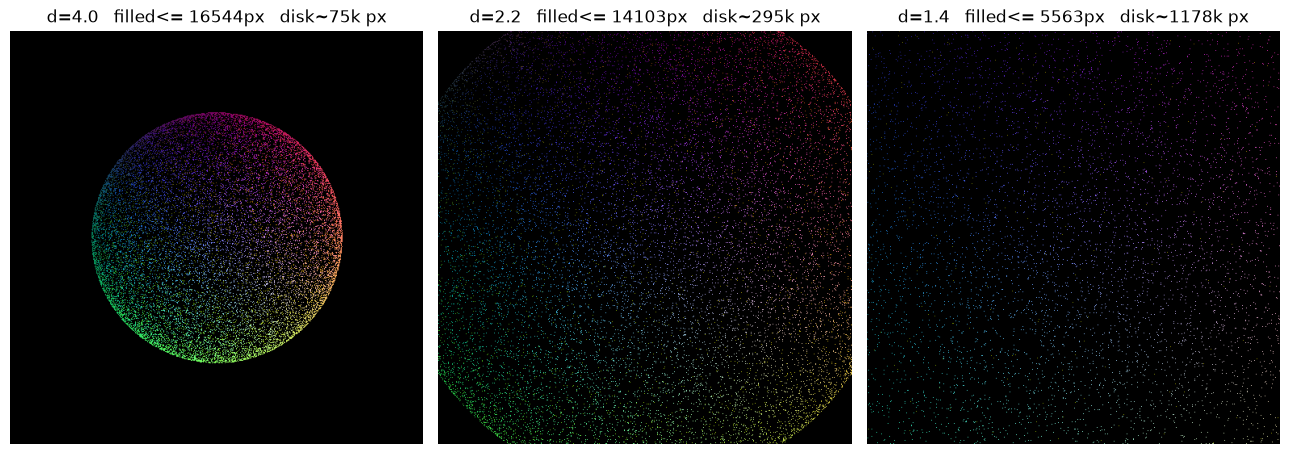

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, d in zip(axes, [4.0, 2.2, 1.4]):
    img, nvis, nfill = render_points(P, C, eye=[0, 0, -d])
    R_sil = 600.0 / np.sqrt(d * d - 1)           # silhouette radius, px
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"d={d}   filled<= {nfill}px   disk~{np.pi * R_sil**2 / 1e3:.0f}k px")
plt.tight_layout()
plt.show()

## Diagnosis

The holes and the transparency are one bug. A point is dimensionless. Its
screen footprint is one pixel regardless of where it is or what surface it
belongs to, so the amount of image a point covers has no connection to the
geometry it represents. Coverage is a fixed budget of N pixels spread over an
area that grows without bound as the camera approaches.

Sorting cannot fix this. A z-buffer cannot fix this. Ten times the points
just moves the density at which it fails.

The primitive needs extent, and the extent has to come out of the projection,
not be tuned by hand.

## Exercise

Give a point a physical radius `s` in world units. Using only the pinhole
formula, derive its radius in pixels at camera depth `z`. Then look at the
expression as `z` shrinks toward 0 and as `z` grows large, and state what
each end implies for a renderer whose camera can move anywhere.

Work it before scrolling.

## Solution

A sphere of radius $s$ at depth $z$ spans world extent $s$ perpendicular to
the view ray, so its screen radius is

$$r_\text{px} = \frac{f_x s}{z}
\qquad\text{exactly } \frac{f_x s}{\sqrt{z^2 - s^2}}\text{, same limit}$$

As $z \to 0$ the footprint is unbounded: one primitive can cover the entire
screen, so per-primitive cost is unbounded too. Consequences we now own:
a near-plane cull is mandatory, and any fast renderer must bound the work a
single primitive can generate (this is where per-pixel-region culling will
come from).

As `z -> inf` the footprint drops below one pixel and we are back to
sub-pixel sampling, a different failure (aliasing) that notebook 02 exhibits
and fixes.

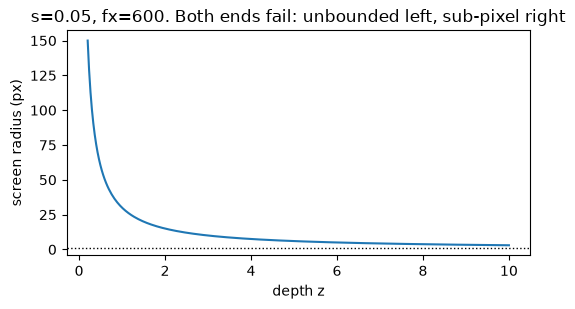

In [5]:
z = np.linspace(0.2, 10, 300)
plt.figure(figsize=(5.5, 3.2))
plt.plot(z, 600 * 0.05 / z)
plt.axhline(1, ls=":", c="k", lw=1)
plt.xlabel("depth z")
plt.ylabel("screen radius (px)")
plt.title("s=0.05, fx=600. Both ends fail: unbounded left, sub-pixel right")
plt.tight_layout()
plt.show()

Next: a primitive with extent. Notebook 02.